In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

In [2]:
def load_grayscale_image(path):
    """
    读取灰度图并归一化到 [0, 1]
    """
    img = Image.open(path).convert('L')
    arr = np.asarray(img, dtype=np.float64) / 255.0
    return arr


def extract_patches(img, patch_size=4, stride=1):
    """
    从图像中提取 patch_size x patch_size 的小块
    每个块展平成长度为 patch_size^2 的列向量
    返回形状: (num_patches, patch_size*patch_size)
    """
    h, w = img.shape
    patches = []

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            patch = img[i:i + patch_size, j:j + patch_size]
            patches.append(patch.flatten())

    return np.array(patches, dtype=np.float64)


def compute_covariance_matrix(samples, remove_mean=True):
    """
    samples: (N, 16), 每一行是一个 16 维样本
    返回:
        mu: 均值向量 (16,)
        Cx: 协方差矩阵 (16,16)
    """
    if remove_mean:
        mu = np.mean(samples, axis=0)
        X = samples - mu
    else:
        mu = np.zeros(samples.shape[1], dtype=np.float64)
        X = samples.copy()

    Cx = (X.T @ X) / X.shape[0]
    return mu, Cx


def plot_basis_functions(U, patch_size=4, cols=4, figsize=(10, 10)):
    """
    将 U 的列向量画成 basis functions
    16 reshape to 4x4
    """
    num_basis = U.shape[1]
    rows = int(np.ceil(num_basis / cols))

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for k in range(num_basis):
        basis = U[:, k].reshape(patch_size, patch_size)

        ax = axes[k]
        im = ax.imshow(basis, cmap='gray')
        ax.set_title(f'Basis {k+1}')
        ax.axis('off')

    for k in range(num_basis, len(axes)):
        axes[k].axis('off')

    plt.tight_layout()
    plt.show()


Mean vector mu shape: (16,)
Covariance matrix Cx shape: (16, 16)


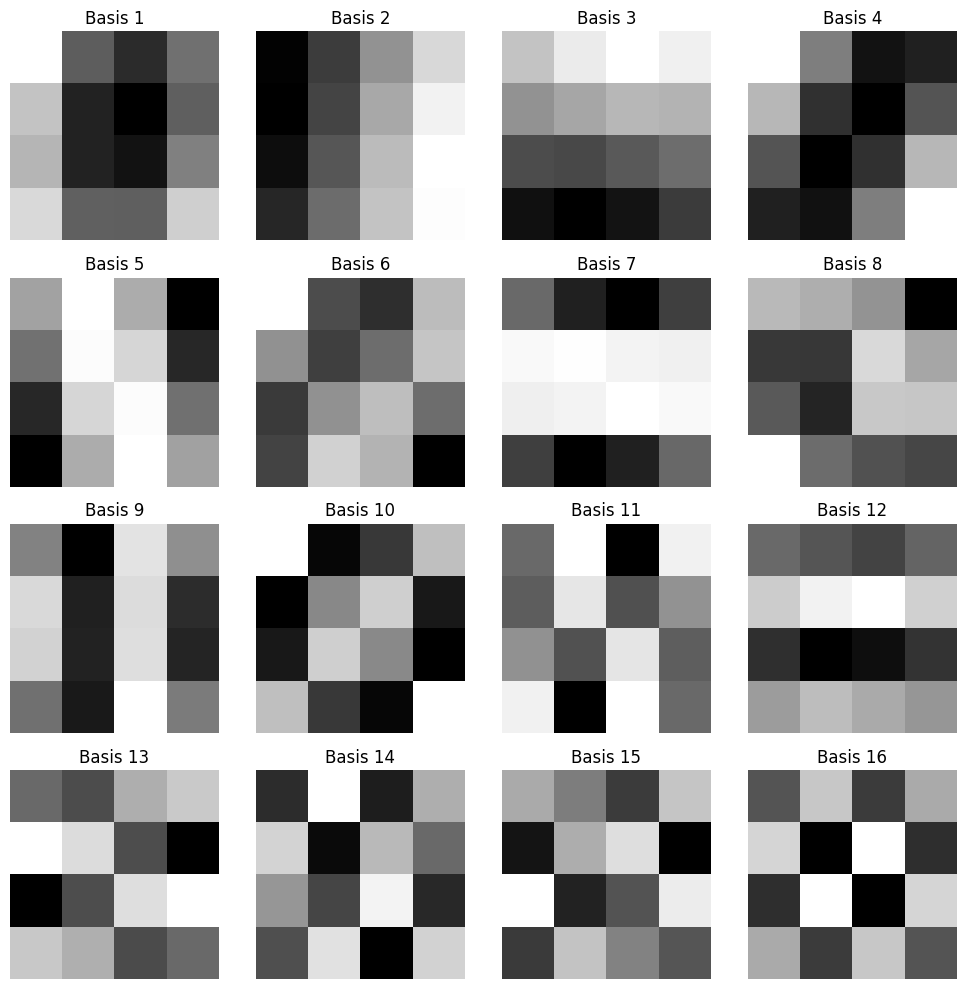

In [3]:
lena = load_grayscale_image('Lenna_(test_image).png')

patch_size = 4
stride = 1

patches_lena = extract_patches(lena, patch_size=patch_size, stride=stride)

samples = np.vstack([patches_lena])

mu, Cx = compute_covariance_matrix(samples, remove_mean=False)

print('\nMean vector mu shape:', mu.shape)
print('Covariance matrix Cx shape:', Cx.shape)

U, S, Vt = np.linalg.svd(Cx)

KLT_basis_matrix = U
KLT_transform_matrix = U.T

plot_basis_functions(KLT_basis_matrix, patch_size=patch_size, cols=4, figsize=(10, 10))